# Map a Z2 lattice to QPU and remove elements corresponding to bad qubits

In [1]:
import os
from pathlib import Path
from qiskit_ibm_runtime import QiskitRuntimeService
from heavyhex_qft.triangular_z2 import TriangularZ2Lattice
from skqd_z2lgt.parameters import Parameters

In [2]:
pkgpath = Path('/data/iiyama/2dz2/validation_fez')
try:
    os.makedirs(pkgpath)
except FileExistsError:
    pass

In [3]:

service = QiskitRuntimeService(instance='ICEPP')
backend = service.backend('ibm_fez', use_fractional_gates=True)

In [4]:
parameters = Parameters(pkgpath=str(pkgpath))
parameters.lgt.lattice = (4, 4)

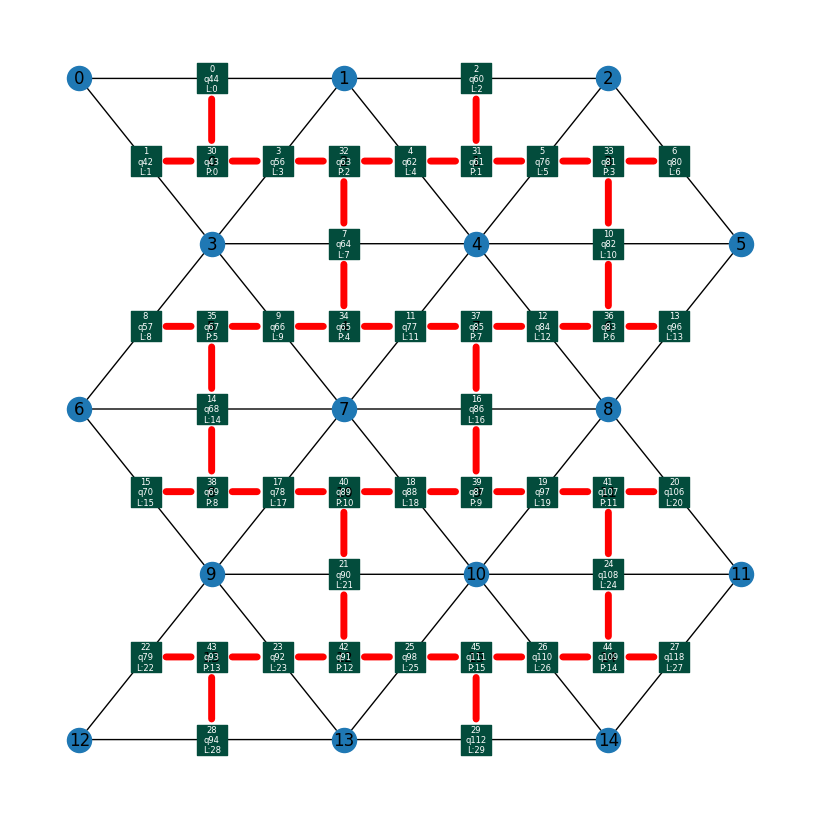

In [5]:
lattice = TriangularZ2Lattice(parameters.lgt.lattice)
layout = lattice.layout_heavy_hex(target=backend.target)
fig = lattice.draw_graph()
lattice.draw_qubit_graph(layout=layout, ax=fig.axes[0])
fig.set_figheight(8)
fig.set_figwidth(8)

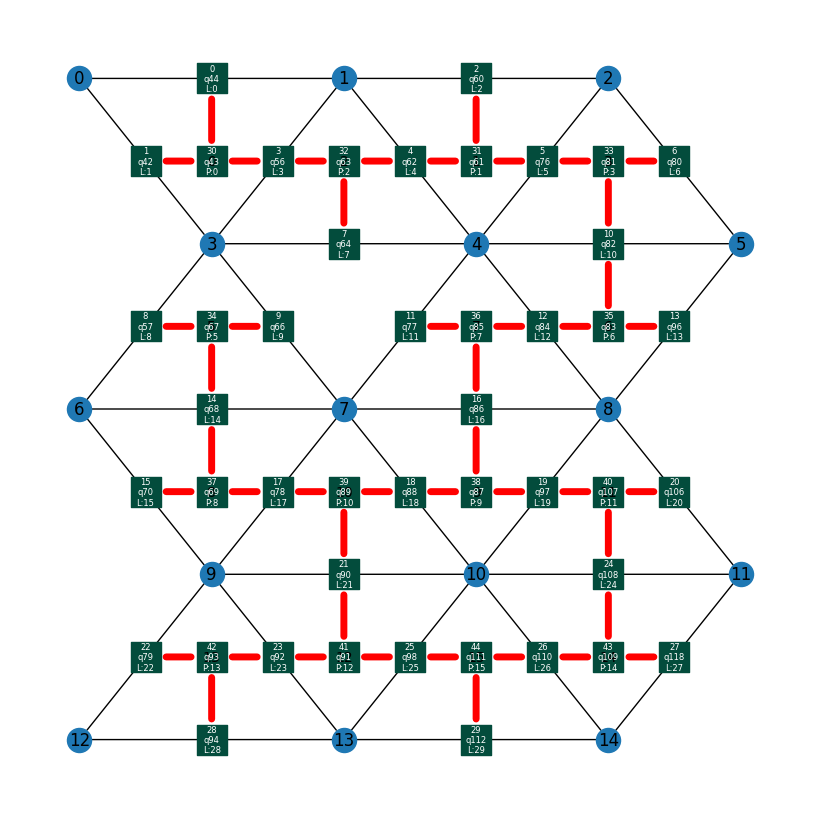

In [6]:
assignment = {qobj.label: layout[iq] for iq, qobj in enumerate(lattice.qubit_graph.nodes())}
assignment.pop('P:4')
lattice.remove_plaquette(4)
parameters.circuit.layout = lattice.layout_heavy_hex(target=backend.target, qubit_assignment=assignment)
fig = lattice.draw_graph()
lattice.draw_qubit_graph(layout=parameters.circuit.layout, ax=fig.axes[0])
fig.set_figheight(8)
fig.set_figwidth(8)

In [7]:
jsonpath = str(pkgpath / 'lattice.json')
with open(jsonpath, 'w') as out:
    out.write(lattice.to_json())

parameters.lgt.lattice = jsonpath